In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from constants import *
from preprocessing import load_house_df

import warnings
warnings.filterwarnings("ignore")

set_project_theme()
pd.set_option("display.width", 120)
%matplotlib inline

In [2]:
house_df = load_house_df()
house_df.head()

,international,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,should_recieve_housing,HO,A1,A2,A3,A4,grades_raw,grade_format,international_bin,age_group
0,domestic,26,2,31.1,62.93,5.8,46.488294,1,1,0,1,0,0,4.34,numeric_0_10,0,25 or older
1,domestic,27,5,13.2,66.45,5.9,61.705686,1,1,0,1,1,0,4.83,numeric_0_10,0,25 or older
2,domestic,25,5,9.8,50.23,5.2,50.063158,1,0,0,0,0,0,NaN,missing,0,25 or older
3,domestic,21,2,20.2,56.99,5.7,3.631151,1,1,0,0,1,0,2.06,numeric_0_10,0,under 25
4,domestic,34,7,51.9,32.31,4.6,43.430483,0,0,0,0,0,0,4.24,numeric_0_10,0,25 or older


# Section 4.2: Equality of False Negatives

A false negative here is a student with `should_recieve_housing == 1` who was refused. Equality of false negatives
asks for the false negative rate to be the same in every group,

$$P(S = 0 \mid T = 1, G = g) \text{ is the same for every group } g$$

so this time we condition on the target and not on the decision. `a` is the false negative rate of group 1, `b` of
group 0. Margin is again 5 percentage points.

In [3]:

def calculate_equality_of_false_negatives(G, T, predictors, margin=MARGIN):
    n_group_1, n_group_0 = sum((T==1) * (G==1)), sum((T==1) * (G==0))
    assert n_group_1 > 0 and n_group_0 > 0, f'one group has no positives: n1={n_group_1}, n0={n_group_0}'
    print(f'students with T=1 -> group 1: {n_group_1}, group 0: {n_group_0}')

    equality_of_false_negatives = pd.DataFrame(
        index=predictors,
        columns=['fair', 'a', 'b', '|a-b|'])

    for predictor in predictors:
        S = house_df[predictor]
        try: a = sum((G==1)*(T==1)*(S==0)) / sum((T==1) * (G==1))
        except: a = 0
        try: b = sum((G==0)*(T==1)*(S==0)) / sum((T==1) * (G==0))
        except: b = 0


        equality_of_false_negatives.loc[ equality_of_false_negatives.index == predictor, ['a',] ] = a
        equality_of_false_negatives.loc[ equality_of_false_negatives.index == predictor, ['b',] ] = b
        equality_of_false_negatives.loc[ equality_of_false_negatives.index == predictor, ['|a-b|',] ] = abs(a - b)
        equality_of_false_negatives.loc[ equality_of_false_negatives.index == predictor, ['fair',] ] = (abs(a - b) <= margin)

    return equality_of_false_negatives.astype(float).round(3)

### Age

In [4]:
G = house_df.age < 25
T = house_df.should_recieve_housing
predictors = ['HO', 'A1', 'A2', 'A3', 'A4']

In [5]:
fnr_age = calculate_equality_of_false_negatives(G, T, predictors)
fnr_age

students with T=1 -> group 1: 525, group 0: 350


,fair,a,b,|a-b|
HO,0.0,0.059,0.326,0.267
A1,1.0,0.408,0.451,0.044
A2,1.0,0.189,0.234,0.046
A3,1.0,0.314,0.351,0.037
A4,0.0,0.208,0.551,0.344


This is the exact opposite of the predictive parity result. HO (0.267) and A4 (0.344) fail badly, and they were the
two methods that passed on age before. A1, A2 and A3 pass.

The numbers for A4 are the clearest. Among the older students who should receive housing, 55 percent are refused,
against 21 percent of the younger ones. HO is the same story, it refuses 33 percent of the older students who
should receive housing and only 6 percent of the younger ones. So the two methods that looked best in section 3
are the two that push the older group out.

### International

In [6]:
G = house_df.international == 'international'
T = house_df.should_recieve_housing
print('positives, international:', sum((T==1)*(G==1)), ' domestic:', sum((T==1)*(G==0)))

positives, international: 282  domestic: 593


In [7]:
fnr_international = calculate_equality_of_false_negatives(G, T, predictors)
fnr_international

students with T=1 -> group 1: 282, group 0: 593


,fair,a,b,|a-b|
HO,1.0,0.145,0.175,0.030
A1,0.0,0.270,0.499,0.230
A2,0.0,0.039,0.287,0.248
A3,1.0,0.340,0.324,0.017
A4,0.0,0.262,0.384,0.122


HO (0.030) and A3 (0.017) pass. A1 (0.230), A2 (0.248) and A4 (0.122) fail.

A2 is extreme in the other direction, it refuses only 4 percent of the international students who should receive
housing against 29 percent of the domestic ones. A2 is the method with the largest selection rate overall, and it
spends most of that generosity on international students, which is also why its precision for that group was the
lowest in the previous section.

### Sanity check against section 3


In [8]:
metrics_df = pd.read_csv(RESULTS_DIR / 'performance_metrics.csv', index_col=0)
pp_age = pd.read_csv(RESULTS_DIR / 'predictive_parity_age.csv', index_col=0)
pp_international = pd.read_csv(RESULTS_DIR / 'predictive_parity_international.csv', index_col=0)

In [9]:
check = pd.DataFrame({
    'FNR overall': metrics_df['FNR'],
    'FNR under 25': fnr_age['a'], 'FNR 25 or older': fnr_age['b'],
    'FNR international': fnr_international['a'], 'FNR domestic': fnr_international['b'],
})

check

,FNR overall,FNR under 25,FNR 25 or older,FNR international,FNR domestic
HO,0.166,0.059,0.326,0.145,0.175
A1,0.425,0.408,0.451,0.270,0.499
A2,0.207,0.189,0.234,0.039,0.287
A3,0.329,0.314,0.351,0.340,0.324
A4,0.345,0.208,0.551,0.262,0.384


### All four fairness checks together

In [10]:
fairness_overview = pd.DataFrame({
    'PP age': pp_age['fair_selected'],
    'PP international': pp_international['fair_selected'],
    'FN age': fnr_age['fair'],
    'FN international': fnr_international['fair'],
}).astype(bool)

fairness_overview['passed'] = fairness_overview.sum(axis=1)
fairness_overview

,PP age,PP international,FN age,FN international,passed
HO,True,False,False,True,2
A1,False,True,True,False,2
A2,False,True,True,False,2
A3,False,True,True,True,3
A4,True,False,False,False,1


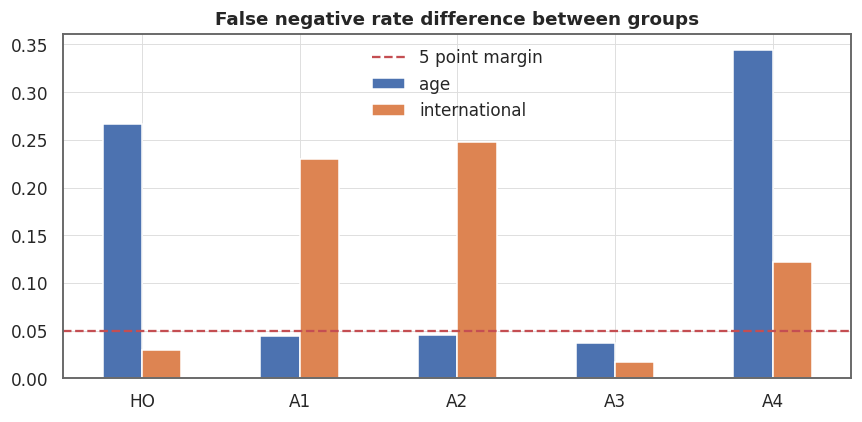

In [11]:
plot_fnr = pd.DataFrame({'age': fnr_age['|a-b|'], 'international': fnr_international['|a-b|']})
plot_fnr.plot(kind='bar', figsize=(8, 4), rot=0)
plt.axhline(0.05, color=MARGIN_COLOR, linestyle='--', label='5 point margin')
plt.title('False negative rate difference between groups')
plt.legend()
plt.tight_layout()
plt.show()

### What we take from this section

No method passes all four checks, and the pattern is almost mirrored. Whenever a method satisfies predictive parity
on a feature, it tends to fail equality of false negatives on that same feature, and the other way round. HO passes
predictive parity on age and fails false negatives on age; A1 and A2 do the reverse.

This is not bad luck, it is expected. The base rate of the target is different in the groups, 48 percent for
students under 25 against 25 percent for the older group, and 48 percent for international against 31 percent for
domestic. When the base rates differ, a method that is not perfectly accurate cannot satisfy both criteria at the
same time, so we have to choose which one matters more in this scenario.

Given that a false negative means a student who needs housing does not get it, we consider equality of false
negatives the more important of the two here. On that reading A3 is the best method, it is the only one that passes
both features on false negatives and it passes 3 of the 4 checks in total. A4 passes only 1 out of 4 and is the
worst on this account, even though it had the best precision and the second best F1 in section 3.

In [12]:
fnr_age.to_csv(RESULTS_DIR / 'false_negatives_age.csv')
fnr_international.to_csv(RESULTS_DIR / 'false_negatives_international.csv')